# Tutorial 5: Integrating developmental mouse brain data
This tutorial demonstrates the capability of SpaTemporal in integrating developing mouse brain data generated by the Stereo-seq platform. The raw data can be downloaded from: https://db.cngb.org/stomics/datasets/STDS0000058.

## Preparation

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

from graph_3D import *
from train import *
from utils import *
from adj import *


libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS


In [2]:
fix_seed(42)

## Load Data and Construction Neighbor Graph

In [3]:
data_root = Path('../Data/Mouse_Embryo_Brain/')

proj_list = [
    'E12.5_E1S2', 'E13.5_E1S2', 'E14.5_E1S1', 'E15.5_E1S1', 'E16.5_E1S1'
]

In [4]:
for adata_name in tqdm(proj_list):
    adata_tmp = sc.read_h5ad(os.path.join(data_root, adata_name + '.Brain.MOSTA.h5ad'))
    adata_tmp.var_names_make_unique()

    adata_tmp.obs['batch_name'] = adata_name
    graph_dict_tmp = main(adata_tmp, adj_cons_by='coordinate', distType='KNN', k_cutoff=8, rad_cutoff=250)
    
    ##### Load layer_guess label, if have
    #df_label = pd.read_csv(data_root / adata_name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
    #df_label.columns = ['layer_guess']
    #adata_tmp.obs['layer_guess'] = df_label['layer_guess']
    #adata_tmp= adata_tmp[~pd.isnull(adata_tmp.obs['layer_guess'])]
    
    if adata_name == proj_list[0]:
        adata = adata_tmp
        graph_dict = graph_dict_tmp
        name = adata_name
        adata.obs['adata_name'] = adata_name
    else:
        var_names = adata.var_names.intersection(adata_tmp.var_names)
        adata = adata[:, var_names]
        adata_tmp = adata_tmp[:, var_names]
        adata_tmp.obs['adata_name'] = adata_name
    
        adata = adata.concatenate(adata_tmp)
        graph_dict = combine_graph_dict(graph_dict, graph_dict_tmp)
        name = name + '_' + adata_name

  0%|          | 0/5 [00:00<?, ?it/s]

------Calculating spatial graph...
The graph contains 76448 edges, 9556 cells.
8.0000 neighbors per cell on average.


 20%|██        | 1/5 [00:02<00:10,  2.67s/it]

------Calculating spatial graph...
The graph contains 97816 edges, 12227 cells.
8.0000 neighbors per cell on average.


 40%|████      | 2/5 [00:11<00:18,  6.03s/it]

...

 60%|██████    | 3/5 [00:28<00:22, 11.09s/it]

------Calculating spatial graph...
The graph contains 136344 edges, 17043 cells.
8.0000 neighbors per cell on average.


 80%|████████  | 4/5 [00:55<00:17, 17.59s/it]

------Calculating spatial graph...
The graph contains 135256 edges, 16907 cells.
8.0000 neighbors per cell on average.


100%|██████████| 5/5 [01:35<00:00, 19.08s/it]


## Data Preprocessing

In [5]:
adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

## Running SpaTemporal

In [7]:
my_net = Train(adata, graph_dict, rec_weight=1, self_weight=1, tri_weight=1, pre_epochs=500, epochs=500, mask_rate=0.2, lr=5e-4, decay=1e-4, mask_mode='token', device='cuda:0')
# my_net = Train(adata, graph_dict, rec_weight=1, self_weight=20, tri_weight=1, pre_epochs=500, epochs=500, mask_rate=0.2, lr=5e-4, decay=1e-4, mask_mode='token', device='cuda:0')
my_net.train_final_model(num_cluster=15, method='kmeans')

get_gpu_memory()

100%|██████████| 500/500 [09:00<00:00,  1.08s/it, Rec_L=1.8974, Self_L=0.1396, Total_L=2.0975, Tri_L=0.0605]  


GPU 0: 22135 MiB / 24564 MiB


In [8]:
latent_z, x_recon = my_net.embedding()
adata.obsm['latent'] = latent_z
adata.obsm['x_recon'] = x_recon

## Clustering

In [13]:
mclust_R(adata, num_cluster=18, used_obsm='latent')

fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 73333 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - Ahr', 'Regulon - Alx1', 'Regulon - Alx3', 'Regulon - Alx4', 'Regulon - Arid3a', 'Regulon - Arid3c', 'Regulon - Arnt', 'Regulon - Arx', 'Regulon - Atf1', 'Regulon - Atf2', 'Regulon - Atf4', 'Regulon - Atf6b', 'Regulon - Atf7', 'Regulon - Atoh1', 'Regulon - Bach1', 'Regulon - Barhl1', 'Regulon - Bcl6b', 'Regulon - Bclaf1', 'Regulon - Bhlhe22', 'Regulon - Bmyc', 'Regulon - Borcs8', 'Regulon - Brca1', 'Regulon - Brf1', 'Regulon - Brf2', 'Regulon - Bsx', 'Regulon - Cdx1', 'Regulon - Cdx2', 'Regulon - Cebpa', 'Regulon - Cebpd', 'Regulon - Cebpe', 'Regulon - Cebpg', 'Regulon - Cebpz', 'Regulon - Chd1', 'Regulon - Chd2', 'Regulon - Clock', 'Regulon - Creb1', 'Regulon - Creb3', 'Regulon - Creb3l1', 'Regulon - Creb3l2', 'Regulon - Crem', 'Regulon - Crx', 'Regulon - Ctcf', 'Regulon - Ctcfl', 'Regulon - Cux1', 'Regulon - D3Ertd254

## Spatial Visualization

In [14]:
colors_default = ['#1f77b4', '#ff7f0f', '#279e68', '#d62728', '#aa40fc',
                  '#8c564b', '#e377c2', '#b5bd61', "#138d9b", "#8fadd4", 
                  '#ffbb78', '#98df8a', '#ff9896', "#ab7fce", "#c4a29b",
                  '#f7b6d2', "#949465", "#5bbecf", "#b96465", "#4728b6",
                  "#d8d834", "#e92490", "#9e075f", "#2e041e", '#7f7f7f',]
adata.uns['mclust_colors'] = [colors_default[0:][i] for i in np.sort(adata.obs['mclust'].unique().astype('int'))]

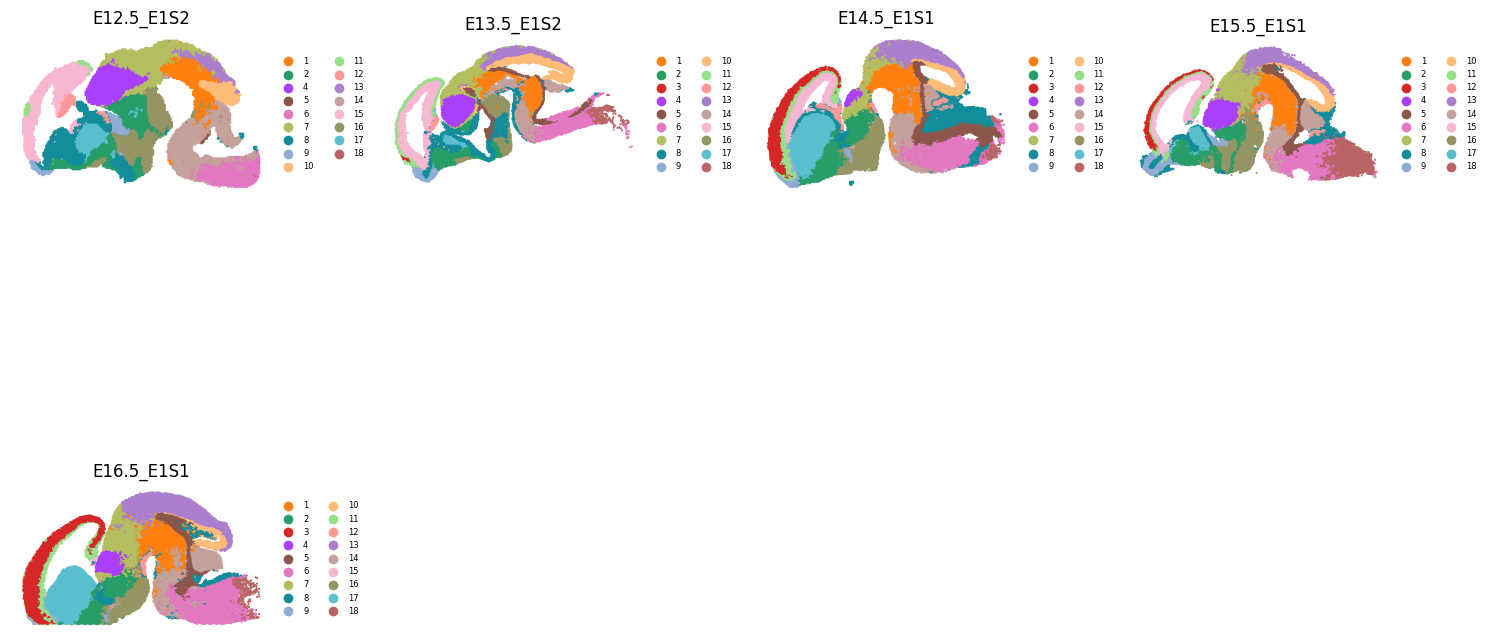

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
k = 1
spot_size = 2
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['adata_name'] == proj_list[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()